In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Monte_Carlo import run_mc1
from Regeneration_of_Size_Effect import Energy_corrected1, eta2

In [39]:
seed = 0

N_values = [2, 8, 32, 104]
kappa_values = np.linspace(1, 10, 19)

alpha = np.sqrt(np.pi)
n_cut = 1
m_cut = 6

step_size = 0.05

# smoke test
n_burnin = 0
n_sweeps = 2
sample_every = 1

In [40]:
def make_neutral_charges(n, seed=0):
    if n % 2 != 0:
        raise ValueError("n must be even.")

    q = np.ones(n, dtype=int)
    q[n // 2:] = -1

    rng = np.random.default_rng(seed)
    rng.shuffle(q)

    return q

In [41]:
records = []

for n in N_values:
    q = make_neutral_charges(n, seed=seed)

    for k in kappa_values:
        print(f"Running N={n}, kappa={k}")

        a = np.sqrt(4.0 * eta2 / (np.pi * n))

        snapshots, U1_trace, acceptance_rate = run_mc1(
            N=n,
            q=q,
            kappa=k,
            a=a,
            alpha=alpha,
            n_cut=n_cut,
            m_cut=m_cut,
            step_size=step_size,
            n_sweeps=n_sweeps,
            sample_every=sample_every,
            n_burnin=n_burnin,
            seed=seed,
        )

        y_corrected = Energy_corrected1(U1_trace, n)

        records.append({
            "N": n,
            "kappa": k,
            "x_inverse_kappa": 1.0 / k,
            "a": a,
            "y_corrected": y_corrected,
            "U1_mean": np.mean(U1_trace),
            "acceptance_rate": acceptance_rate,
            "n_samples": len(U1_trace),
        })

Running N=2, kappa=1.0
Running N=2, kappa=1.5
Running N=2, kappa=2.0
Running N=2, kappa=2.5
Running N=2, kappa=3.0
Running N=2, kappa=3.5
Running N=2, kappa=4.0
Running N=2, kappa=4.5
Running N=2, kappa=5.0
Running N=2, kappa=5.5
Running N=2, kappa=6.0
Running N=2, kappa=6.5
Running N=2, kappa=7.0
Running N=2, kappa=7.5
Running N=2, kappa=8.0
Running N=2, kappa=8.5
Running N=2, kappa=9.0
Running N=2, kappa=9.5
Running N=2, kappa=10.0
Running N=8, kappa=1.0
Running N=8, kappa=1.5
Running N=8, kappa=2.0
Running N=8, kappa=2.5
Running N=8, kappa=3.0
Running N=8, kappa=3.5
Running N=8, kappa=4.0
Running N=8, kappa=4.5
Running N=8, kappa=5.0
Running N=8, kappa=5.5
Running N=8, kappa=6.0
Running N=8, kappa=6.5
Running N=8, kappa=7.0
Running N=8, kappa=7.5
Running N=8, kappa=8.0
Running N=8, kappa=8.5
Running N=8, kappa=9.0
Running N=8, kappa=9.5
Running N=8, kappa=10.0
Running N=32, kappa=1.0
Running N=32, kappa=1.5
Running N=32, kappa=2.0
Running N=32, kappa=2.5
Running N=32, kappa=3.0
Runn

In [42]:
df = pd.DataFrame(records)
df.to_csv("fig2b_energy_data.csv", index=False)
df

,N,kappa,x_inverse_kappa,a,y_corrected,U1_mean,acceptance_rate,n_samples
0,2,1.0,1.000000,0.056419,0.915059,-1.044833,1.000000,2
1,2,1.5,0.666667,0.056419,0.915059,-1.044833,1.000000,2
2,2,2.0,0.500000,0.056419,0.915059,-1.044833,1.000000,2
3,2,2.5,0.400000,0.056419,0.915059,-1.044833,1.000000,2
4,2,3.0,0.333333,0.056419,0.915059,-1.044833,1.000000,2
...,...,...,...,...,...,...,...,...
71,104,8.0,0.125000,0.007824,1.519733,-94.177482,0.538462,2
72,104,8.5,0.117647,0.007824,1.527737,-93.345094,0.548077,2
73,104,9.0,0.111111,0.007824,1.525692,-93.557721,0.548077,2
74,104,9.5,0.105263,0.007824,1.525692,-93.557721,0.548077,2


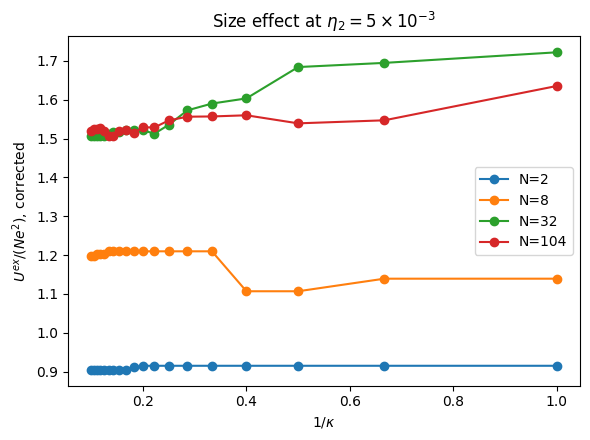

In [ ]:
plt.figure(figsize=(6, 4.5))

for n in N_values:
    sub = df[df["N"] == n].sort_values("x_inverse_kappa")

    plt.plot(
        sub["x_inverse_kappa"],
        sub["y_corrected"],
        marker="o",
        label=f"N={n}",
    )

plt.xlabel(r"$1/\kappa$")
plt.ylabel(r"$U/N e^2$")
plt.title(r"Size effect at $\eta_2=5\times 10^{-3}$")
plt.legend()
plt.tight_layout()
plt.show()